In [1]:
import pandas as pd
import geemap
from google.colab import drive
import geopandas as gpd
import ee
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

# Autenticación e inicialización
drive.mount('/content/drive')
ee.Authenticate()
ee.Initialize(project='lucasvituri')

# 1. Carga y reproyección de Shapes
provincias = gpd.read_file('/content/drive/MyDrive/INTROSIG_T1_GEE/Provincias.shp').to_crs('EPSG:4326')
catastro = gpd.read_file('/content/drive/MyDrive/INTROSIG_T1_GEE/5__cubierta_frutal_de_pol_gonos_regi_n_de_valpara_so_2025.shp').to_crs('EPSG:4326')

# 2. Intersección Espacial
catastro_con_provincia = gpd.overlay(catastro, provincias, how='intersection')

# 3. Creación de la Interfaz Interactiva
provincias_list = sorted(catastro_con_provincia['Provincia'].dropna().unique().tolist())
especies_list = sorted(catastro_con_provincia['ESPECIE'].dropna().unique().tolist())

style = {'description_width': 'initial'}
prov_dropdown = widgets.Dropdown(options=provincias_list, description='📍 Provincia:', style=style)
esp1_dropdown = widgets.Dropdown(options=especies_list, description='🌱 Especie 1:', value='PALTO', style=style)
esp2_dropdown = widgets.Dropdown(options=especies_list, description='🌱 Especie 2:', value='VID DE MESA', style=style)

# Mostrar menús
display(widgets.HBox([prov_dropdown, esp1_dropdown, esp2_dropdown]))

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: organizePolygons() received an unexpected geometry.  Either a polygon with interior rings, or a polygon with less than 4 points, or a non-Polygon geometry.  Return arguments as a collection.
  return ogr_read(
/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:200: RuntimeWarning: Geometry of polygon of fid 56 cannot be translated to Simple Geometry. All polygons will be contained in a multipolygon.
  return ogr_read(


In [3]:
# Obtenemos los valores elegidos por el usuario en la interfaz
PROVINCIA = prov_dropdown.value
ESPECIE_1 = esp1_dropdown.value
ESPECIE_2 = esp2_dropdown.value

# Filtramos los geodataframes
prov_gdf = provincias[provincias['Provincia'] == PROVINCIA]
esp1_sf = catastro_con_provincia[(catastro_con_provincia['Provincia'] == PROVINCIA) & (catastro_con_provincia['ESPECIE'] == ESPECIE_1)]
esp2_sf = catastro_con_provincia[(catastro_con_provincia['Provincia'] == PROVINCIA) & (catastro_con_provincia['ESPECIE'] == ESPECIE_2)]

print(f"Parcelas procesadas en {PROVINCIA}:\n- {ESPECIE_1}: {len(esp1_sf)} polígonos\n- {ESPECIE_2}: {len(esp2_sf)} polígonos")

# Función de Extracción (Mantenemos tu robusta implementación con BBOX)
def extract_by_bbox(gdf, label):
    if gdf.empty:
        return {'features': []} # Previene errores si no hay especie en la provincia

    region = geemap.geopandas_to_ee(gdf).geometry().bounds()
    smap_col = ee.ImageCollection("NASA/SMAP/SPL4SMGP/008")
    ndvi_col = ee.ImageCollection("MODIS/061/MOD13Q1")

    def monthly_stat(m):
        m = ee.Number(m)
        ini = ee.Date.fromYMD(2023, m, 1)
        fin = ini.advance(1, 'month')

        temp = smap_col.filterDate(ini, fin).select('surface_temp').mean().subtract(273.15).reduceRegion(
            reducer=ee.Reducer.mean(), geometry=region, scale=11000).get('surface_temp', 0)

        ndvi = ndvi_col.filterDate(ini, fin).select('NDVI').mean().multiply(0.0001).reduceRegion(
            reducer=ee.Reducer.mean(), geometry=region, scale=250).get('NDVI', 0)

        return ee.Feature(None, {'Mes': m, 'Temperatura': temp, 'NDVI': ndvi, 'Especie': label})

    return ee.FeatureCollection(ee.List.sequence(1, 12).map(monthly_stat)).getInfo()

# Consolidamos los datos en la tabla (Producto 1)
print("Extrayendo variables biofísicas desde GEE...")
res_esp1 = extract_by_bbox(esp1_sf, ESPECIE_1)
res_esp2 = extract_by_bbox(esp2_sf, ESPECIE_2)

df_comparativo = pd.DataFrame([f['properties'] for f in res_esp1['features']] +
                              [f['properties'] for f in res_esp2['features']])

display(df_comparativo)

Parcelas procesadas en Quillota:
- OLIVO: 20 polígonos
- KIWI: 18 polígonos
Extrayendo variables biofísicas desde GEE...


,Especie,Mes,NDVI,Temperatura
0,OLIVO,1,0.461343,19.852896
1,OLIVO,2,0.436522,21.094189
2,OLIVO,3,0.440832,19.968281
3,OLIVO,4,0.444311,16.240641
4,OLIVO,5,0.456593,13.190995
5,OLIVO,6,0.456249,11.823241
6,OLIVO,7,0.535796,10.863226
7,OLIVO,8,0.617830,12.203996
8,OLIVO,9,0.630981,11.950196
9,OLIVO,10,0.580201,13.725353


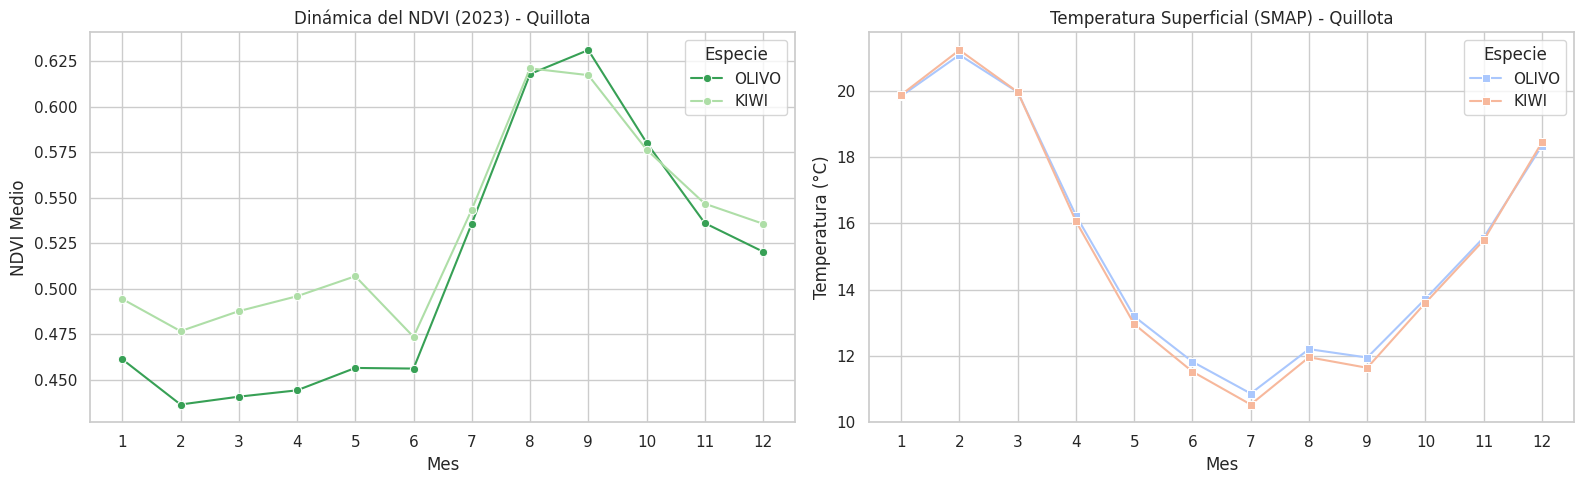

In [4]:
# Configuramos estilo de Seaborn
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico de NDVI
sns.lineplot(data=df_comparativo, x='Mes', y='NDVI', hue='Especie', marker="o", ax=axes[0], palette="Greens_r")
axes[0].set_title(f'Dinámica del NDVI (2023) - {PROVINCIA}')
axes[0].set_xticks(range(1, 13))
axes[0].set_ylabel('NDVI Medio')

# Gráfico de Temperatura (SMAP)
sns.lineplot(data=df_comparativo, x='Mes', y='Temperatura', hue='Especie', marker="s", ax=axes[1], palette="coolwarm")
axes[1].set_title(f'Temperatura Superficial (SMAP) - {PROVINCIA}')
axes[1].set_xticks(range(1, 13))
axes[1].set_ylabel('Temperatura (°C)')

plt.tight_layout()
plt.show()

In [8]:
# Instanciamos el Mapa
Map = geemap.Map(basemap='SATELLITE')

# Diccionario para construir la leyenda dinámicamente
legend_items = {}

# 1. Definir región de interés, procesar y añadir capas Ráster (Gridded)
if not prov_gdf.empty:
    ee_prov = geemap.geopandas_to_ee(prov_gdf)
    region = ee_prov.geometry()
    Map.centerObject(ee_prov, 10)

    # --- NUEVO: Carga y Filtro de Datos Ráster para el Mapa ---
    # Llamamos a las colecciones usando el mismo rango temporal de tu análisis (2023)
    smap_col = ee.ImageCollection("NASA/SMAP/SPL4SMGP/008").filterDate('2023-01-01', '2023-12-31')
    ndvi_col = ee.ImageCollection("MODIS/061/MOD13Q1").filterDate('2023-01-01', '2023-12-31')

    # Calculamos el promedio anual y aplicamos las ecuaciones de escala/conversión correspondientes
    raster_temp = smap_col.select('surface_temp').mean().subtract(273.15).clip(region)
    raster_ndvi = ndvi_col.select('NDVI').mean().multiply(0.0001).clip(region)

    # Definimos paletas de colores óptimas para cada producto
    viz_temp = {
        'min': 10,
        'max': 32,
        'palette': ['blue', 'cyan', 'green', 'yellow', 'orange', 'red']
    }
    viz_ndvi = {
        'min': 0.1,
        'max': 0.7,
        'palette': ['#FFFFFF', '#CE7E45', '#DF923D', '#F1B555', '#FCD163', '#99B718', '#74A901', '#004C00']
    }

    # Añadimos los Rasters (el último parámetro 'False' hace que la capa inicie apagada en el panel)
    Map.addLayer(raster_temp, viz_temp, 'Temperatura Media 2023 (SMAP - Gridded)', False)
    Map.addLayer(raster_ndvi, viz_ndvi, 'NDVI Medio 2023 (MODIS - Gridded)', True)

    # Dibujamos el límite vectorial de la provincia por encima de los mapas base ráster
    Map.addLayer(ee_prov, {'color': 'white', 'fillColor': '00000000', 'width': 2}, f'Límite {PROVINCIA}')

# 2. Añadir las capas vectoriales de los catastros de especies seleccionadas
if not esp1_sf.empty:
    Map.addLayer(geemap.geopandas_to_ee(esp1_sf), {'color': '2ca02c'}, f'Polígonos: {ESPECIE_1}')
    legend_items[ESPECIE_1] = '#2ca02c'

if not esp2_sf.empty:
    Map.addLayer(geemap.geopandas_to_ee(esp2_sf), {'color': 'd62728'}, f'Polígonos: {ESPECIE_2}')
    legend_items[ESPECIE_2] = '#d62728'

# 3. Agregar componentes interactivos de Interfaz (Leyendas y barras de colores)
if legend_items:
    Map.add_legend(title='Cobertura Agrícola', legend_dict=legend_items)

# Añade una barra de escala en la esquina para interpretar los valores numéricos del NDVI ráster
if not prov_gdf.empty:
    Map.add_colorbar(vis_params=viz_ndvi, label="Escala NDVI (MODIS)", layer_name="NDVI Medio 2023 (MODIS - Gridded)")

# Desplegar mapa final
display(Map)

Map(center=[-32.807114657326856, -71.18295175359837], controls=(WidgetControl(options=['position', 'transparen…